# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 02    |  |
| :-------------|:-------------|
| Ties langeraar | 6541798 |
| Belen de Glas| 6574297 |
| Pieter Broerse | 6507840 |

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 10:45 - 12:30 | Pieter |
| ontwerp-eis berekenen| 10:45 - 12:30 | Belen en Ties|
| Synthese & simulatie | tot 14:00 | hele groep |
| Fabriceren | Tot 15:00 | hele groep |
| Metingen | Tot 15:30  | ---|
| Alles af & itereren | Tot 17:45 (indien nodig) | ---|
| Pauze 1| 12:30 - 13:30 | hele groep |
| Pauze 2| 15:30 - 15:45 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 3 |
| hoe lang voor één meting | 1 minuut |
| verwacht nauwkeurigheid meting | 0.05 |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
#A_m/A_v = 1/3
#omega = 2 *pi*5
#omschrijven geeft

w_0 = (10*np.pi)/2
f_0 = (10*np.pi)/2/(2*np.pi)
print(w_0, f_0)

15.707963267948966 2.5


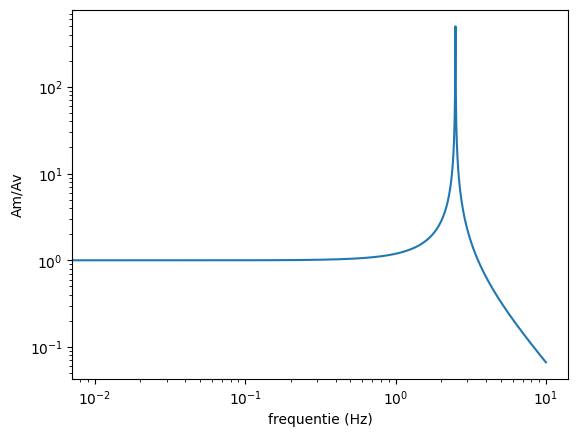

In [3]:
def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

f_test = np.linspace(0,10,1000)

plt.figure()
plt.loglog(f_test,functie(f_test))
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.show()

In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g=9.81 #m/s**2
delta_x=g/(w_0**2)
print(delta_x)




0.039758432461253344


## Opdracht 3: Plot de grafiek.

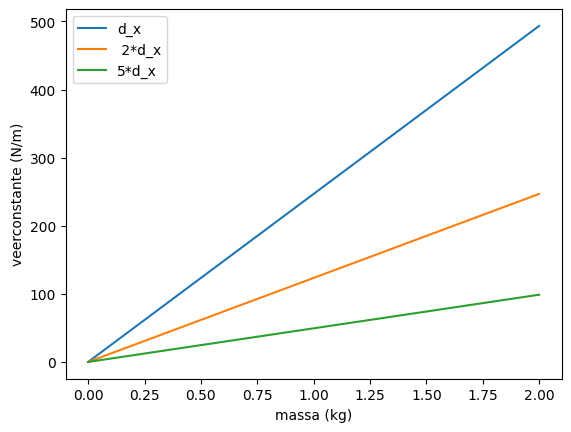

In [5]:
def C_berekenen(m,d_x):
    return g*m/d_x

m_test = np.linspace(0,2,1000)

plt.figure()
plt.plot(m_test,C_berekenen(m_test,delta_x), label = 'd_x' )
plt.plot(m_test,C_berekenen(m_test,2*delta_x), label = ' 2*d_x')
plt.plot(m_test,C_berekenen(m_test,5*delta_x),label='5*d_x')
plt.xlabel('massa (kg)')
plt.ylabel('veerconstante (N/m)')
plt.legend()
plt.show()

In [6]:
#Schattend rekenen

#Veerconstante geschat met behulp van een rol tape die aan de veer is gehangen.
m_tape= 0.573 #kg
C= g*m_tape/0.022
print(C)
L=0.51
A= np.pi*(0.004**2)
print(A)
#youngs modulus 
E= C*L/A
print(E, 'is de geschatte Youngs modulus' )

255.5059090909091
5.0265482457436686e-05
2592395.5618391726 is de geschatte Youngs modulus


## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- veerconsante verlagen
- massa verhogen

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 

In [7]:
#Berekenen benodigde massa, met nieuwe C berekend voor halve veer
delta_x_2 = 0.015
c_opstelling = C_berekenen(m_tape,delta_x_2)
print(c_opstelling)

m_opstelling = (c_opstelling*delta_x)/g

print(m_opstelling)

m_waterfles= m_opstelling -(m_tape)
print(m_waterfles)

#uiteindelijk hebben we een iets zwaardere waterfles kunnen krijgen van 0.980 gram.

374.742
1.5187721200198776
0.9457721200198776


## Opdracht 5: Schets.

##### schets opstelling: 
<img src="IMG_1532.JPG" width="400">
<img src="IMG_1533.JPG" width="400">
<img src="foto4.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

0.04 m

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja, deze waarde wordt behaald als er een massa van ongebeer 1.5 kg aan hangt

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

De veer kan nog ongeveer 20 cm uitrekken

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja dit is genoeg want we redden de uitreiking die we willen behalen makkelijk.

### Gaat je ontwerp dus voldoen aan de eis?

Ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

0.03975843246125334


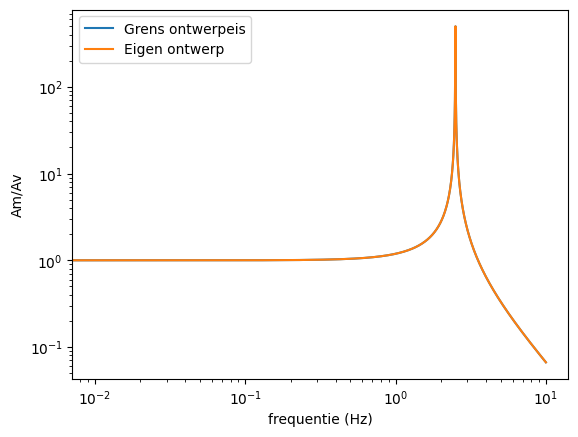

In [8]:
# Voeg hier je plot in.
def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

m_test= m_tape+m_waterfles
d_x_test= g*m_test/c_opstelling
print(d_x_test)
w_0_2= g/d_x_test

def functie_w_2(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0_2)))
f_test = np.linspace(0,10,1000)

plt.figure()
plt.loglog(f_test,functie(f_test),label='Grens ontwerpeis')
plt.loglog(f_test,functie_w_2(f_test),label='Eigen ontwerp')
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

In [9]:
#Nu gaan we itereren met een nieuwe opstellinh met elastieken
delta_x_2 = 0.45-0.22
c_opstelling_2 = C_berekenen(m_tape,delta_x_2)
print(c_opstelling)

m_opstelling_2 = (c_opstelling*delta_x)/g

print(0.573*g/delta_x)

print(m_opstelling_2)

374.742
141.38208304560504
1.5187721200198776


0.22999999999999998


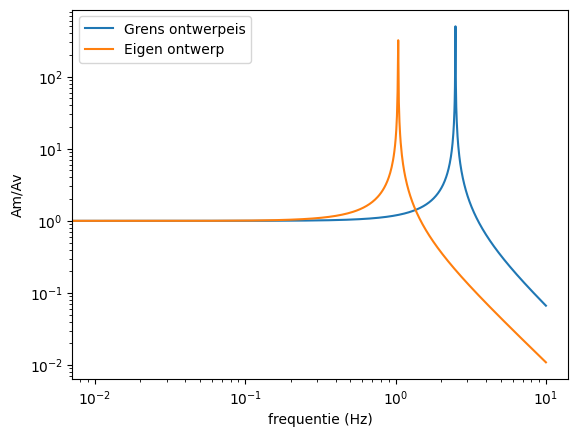

In [10]:
#Simulatie elastiek
def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

m_test= m_tape
d_x_test= g*m_test/c_opstelling_2
print(d_x_test)
w_0_2= g/d_x_test
def functie_w_2(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0_2)))
f_test = np.linspace(0,10,1000)

plt.figure()
plt.loglog(f_test,functie(f_test),label='Grens ontwerpeis')
plt.loglog(f_test,functie_w_2(f_test),label='Eigen ontwerp')
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

## Opdracht 7: Plotten maar

[0.09013878 0.0450284  0.02236068]
[0.1        0.15357143 0.1       ]
0.22999999999999998


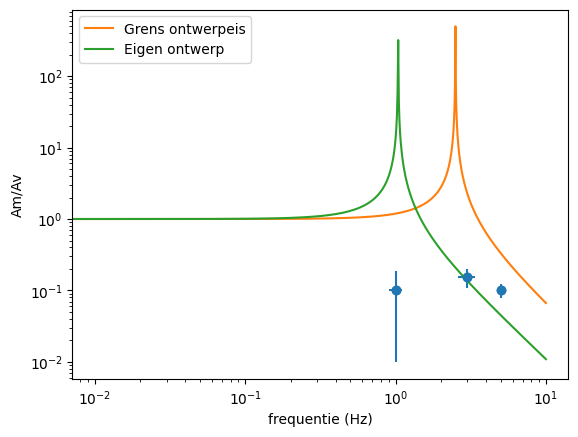

In [11]:
# Voeg hier je plots in.

f=np.array([1,3,5])
u_f=np.array([0.1,0.4,0.3])

Am=np.array([0.2,0.43,0.5])
u_Am=np.array([0.1,0.1,0.1])


Av= np.array([2,2.8,5.0])
u_Av=np.array([1.5,0.5,0.5])


u_vm=np.sqrt(((1/Av)*u_Am)**2+((-Am/Av**2)*u_Av)**2)
print(u_vm)
Am_Av=(Am/Av)
print(Am_Av)

def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

m_test= m_tape
d_x_test= g*m_test/c_opstelling_2
print(d_x_test)
w_0_2= g/d_x_test
def functie_w_2(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0_2)))
f_test = np.linspace(0,10,1000)

plt.figure()
plt.errorbar(f,Am_Av, xerr=u_f,yerr=u_vm, fmt = 'o')
plt.errorbar
plt.loglog(f_test,functie(f_test),label='Grens ontwerpeis')
plt.loglog(f_test,functie_w_2(f_test),label='Eigen ontwerp')
plt.scatter(f,Am_Av)
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

#Verklaring afwijking gemeten punten en onze ontwerpgrafiek
#Op 1 hz wijkt onze meting sterk af van de voorspelde waarde. 
# Dit is logisch want ronde de eigenfrequentie schommelt de waarde van Am/Av erg. bij deze meting hoort dan ook een hele grote onzekerheid. 
#Op 3 Hz komt de meting sterk overeen met de grafiek.
#Op 5 Hz is een iets grotere verhouding tussen Am en Av gemeten dan volgens de grafiek voorspelt is.
#Dit kan als de gemeten frequentie van Am te hoog was, of die van Av te laag.
#  Dit kan komen omdat bij het bewegen van de balk bij een hoge frequentie het aperaat niet snel genoeg de veranderingen registreert.


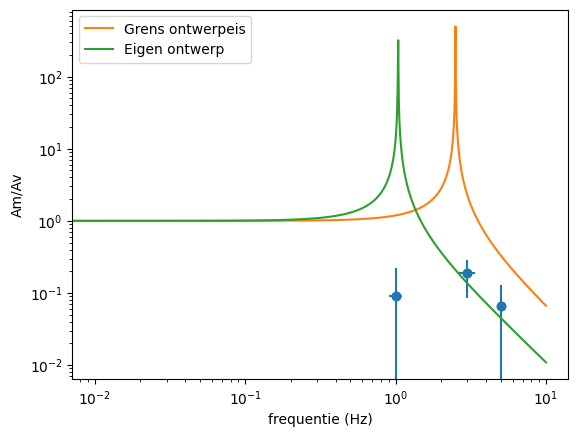

In [12]:
#Meting met de laataste opstelling met twee verdiepingen
f_2=np.array([1,3,5])
u_f=np.array([0.1,0.4,0.3])
A_groen=np.array([0.23,0.6,0.3])
A_rood=np.array([2.5,3.2,4.6])
u_Agroen=np.array([0.3,0.3,0.3])
u_Arood=np.array([1.5,0.7,0.5])

Amv_2= A_groen/A_rood
u_vm2=np.sqrt(((1/A_rood)*u_Agroen)**2+((-A_groen/A_rood**2)*u_Arood)**2)

plt.figure()
plt.errorbar(f_2,Amv_2, xerr=u_f,yerr=u_vm2, fmt = 'o')
plt.errorbar
plt.loglog(f_test,functie(f_test),label='Grens ontwerpeis')
plt.loglog(f_test,functie_w_2(f_test),label='Eigen ontwerp')
plt.scatter(f,Amv_2)
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

In [13]:
#De reden dat de piek bij de eigenfrequentie die wij in ons eigen ontwerp gebruikt hebben veel meer naar links ligt dan de eigenfrquentie van de
#  ontwerpeis, is omdat we een zwaardere massa hebben gebruikt dan nodig was voor de minimale delta x. Onze uitwijking en dus delta x was veel 
# groter dan de minimale waarde, en dus ligt de piek naar links.  

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

# Leerdoel

Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp

In [ ]:
 Voeg hier je plots in.

f=np.array([1,3,5])
u_f=np.array([0.1,0.4,0.3])

Am=np.array([0.2,0.43,0.5])
u_Am=np.array([0.1,0.1,0.1])


Av= np.array([2,2.8,5.0])
u_Av=np.array([1.5,0.5,0.5])


u_vm=np.sqrt(((1/Av)*u_Am)**2+((-Am/Av**2)*u_Av)**2)
print(u_vm)
Am_Av=(Am/Av)
print(Am_Av)

def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

m_test= m_tape
d_x_test= g*m_test/c_opstelling_2
print(d_x_test)
w_0_2= g/d_x_test
def functie_w_2(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0_2)))
f_test = np.linspace(0,10,1000)

plt.figure()
plt.errorbar(f,Am_Av, xerr=u_f,yerr=u_vm, fmt = 'o')
plt.errorbar
plt.loglog(f_test,functie(f_test),label='Grens ontwerpeis')
plt.loglog(f_test,functie_w_2(f_test),label='Eigen ontwerp')
plt.scatter(f,Am_Av)
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

#Verklaring afwijking gemeten punten en onze ontwerpgrafiek
#Op 1 hz wijkt onze meting sterk af van de voorspelde waarde. 
# Dit is logisch want ronde de eigenfrequentie schommelt de waarde van Am/Av erg. bij deze meting hoort dan ook een hele grote onzekerheid. 
#Op 3 Hz komt de meting sterk overeen met de grafiek.
#Op 5 Hz is een iets grotere verhouding tussen Am en Av gemeten dan volgens de grafiek voorspelt is.
#Dit kan als de gemeten frequentie van Am te hoog was, of die van Av te laag.
#  Dit kan komen omdat bij het bewegen van de balk bij een hoge frequentie het aperaat niet snel genoeg de veranderingen registreert.


In [15]:
#Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen. 
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g=9.81 #m/s**2
delta_x=g/(w_0**2)
print(delta_x)


0.039758432461253344


In [16]:
def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

m_test= m_tape
d_x_test= g*m_test/c_opstelling_2
print(d_x_test)
w_0_2= g/d_x_test
def functie_w_2(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0_2)))
f_test = np.linspace(0,10,1000)

0.22999999999999998


In [17]:
#Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp. 

In [18]:
delta_x_2 = 0.015
c_opstelling = C_berekenen(m_tape,delta_x_2)
print(c_opstelling)

m_opstelling = (c_opstelling*delta_x)/g

print(m_opstelling)

m_waterfles= m_opstelling -(m_tape)
print(m_waterfles)

374.742
1.5187721200198776
0.9457721200198776


In [19]:
#schetsen
#


<img src="IMG_1532.JPG" width="400">
<img src="IMG_1533.JPG" width="400">
<img src="foto4.jpeg" width="400">

# Leerdoel: 
inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen.

0.22999999999999998


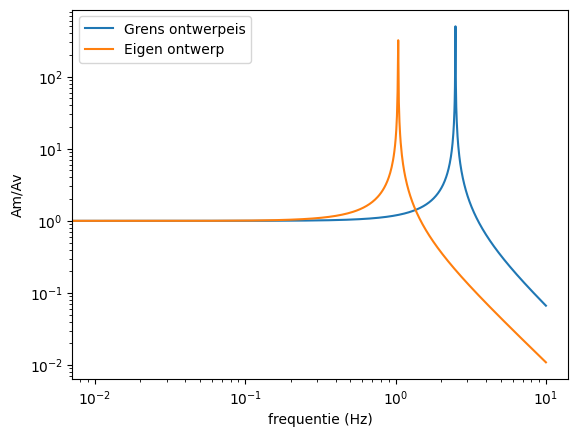

In [20]:
#Simulatie elastiek
def functie(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0**2)))

m_test= m_tape
d_x_test= g*m_test/c_opstelling_2
print(d_x_test)
w_0_2= g/d_x_test
def functie_w_2(f_0):
    return np.abs(1/(1-((2*np.pi*f_0)**2/w_0_2)))
f_test = np.linspace(0,10,1000)

plt.figure()
plt.loglog(f_test,functie(f_test),label='Grens ontwerpeis')
plt.loglog(f_test,functie_w_2(f_test),label='Eigen ontwerp')
plt.xlabel('frequentie (Hz)')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

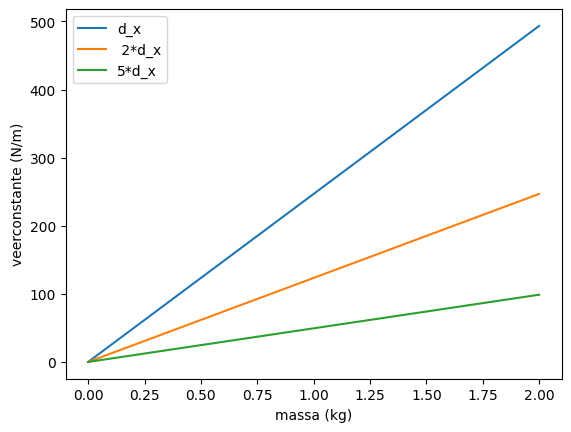

In [22]:
def C_berekenen(m,d_x):
    return g*m/d_x

m_test = np.linspace(0,2,1000)

plt.figure()
plt.plot(m_test,C_berekenen(m_test,delta_x), label = 'd_x' )
plt.plot(m_test,C_berekenen(m_test,2*delta_x), label = ' 2*d_x')
plt.plot(m_test,C_berekenen(m_test,5*delta_x),label='5*d_x')
plt.xlabel('massa (kg)')
plt.ylabel('veerconstante (N/m)')
plt.legend()
plt.show()



#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:
<img src="tudelftLogo.png" width="400">
<img src="tudelftLogo.png" width="400">